# Exercise 1

In [151]:
import matplotlib.pyplot as plt

# Plotting style
import seaborn as sns
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

import pandas as pd
import numpy as np
import statsmodels.api as sm

### 0) Indlæser data

In [152]:
df = pd.read_csv("Caschool.csv")

# Displaying the dataframe.
display(df.head())

,Unnamed: 0,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024


In [153]:
# Sortere for san Diego County og laver sin egen data frame
df_sandiego = df.loc[df['county'] == 'San Diego']

# Fjerner Fra den oprindelige data frame 
df = df[df['county'] != 'San Diego']

df_sandiego.head()

,Unnamed: 0,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
30,31,68379,San Diego,San Ysidro Elementary,KK-08,4142,201.000000,35.562500,81.506500,569,624.550049,0.137373,5342.233398,20.606966,6.61300,80.420090,620.400024,628.700012
68,69,68221,San Diego,National Elementary,KK-06,6639,304.730011,26.841400,100.000000,505,634.099976,0.076066,5339.391113,21.786499,8.42300,58.081036,631.500000,636.700012
117,118,68395,San Diego,South Bay Union Elementary,KK-06,10218,508.750000,17.420200,70.806396,1435,641.449951,0.140438,5518.702148,20.084520,10.60247,41.133293,638.599976,644.299988
145,146,68205,San Diego,Lemon Grove Elementary,KK-08,4612,232.970001,17.476101,65.915001,601,645.550049,0.130312,5124.836426,19.796539,12.82700,16.652212,647.700012,643.400024
159,160,68023,San Diego,Chula Vista Elementary,KK-06,21338,1051.579956,13.227200,45.994999,2889,647.250000,0.135392,5123.474121,20.291372,14.29830,34.337799,645.000000,649.500000


### a) Descriptive statistics

Kan udvides når vi ved hvilke parametre vi vælger i modellen

In [155]:
# Lav først eventuelt elevprlærer, hvis den ikke allerede findes
df['elevprlærer'] = df['enrltot'] / df['teachers']
df['computerprelev'] = df['computer'] / df['enrltot']

In [156]:
df[['mathscr', 'calwpct', 'computerprelev', 'elevprlærer', 'expnstu', 'elpct', 'mealpct', 'avginc']].describe()

,mathscr,calwpct,computerprelev,elevprlærer,expnstu,elpct,mealpct,avginc
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,652.919047,13.403622,0.136249,19.631369,5307.119603,15.429893,44.937275,15.204403
std,18.755678,11.559538,0.065405,1.901437,644.263914,18.127411,27.187718,7.235224
min,605.400024,0.000000,0.000000,14.000000,3926.069580,0.000000,0.000000,5.335000
25%,638.700012,4.469800,0.092863,18.585708,4893.213135,1.780019,23.541451,10.634000
50%,651.900024,10.593200,0.124060,19.643900,5211.485352,8.662933,42.446800,13.630000
75%,665.400024,19.307400,0.167880,20.849567,5596.902100,22.781713,66.927853,17.507999
max,709.500000,78.994202,0.420833,25.800000,7711.506836,85.539719,100.000000,55.327999


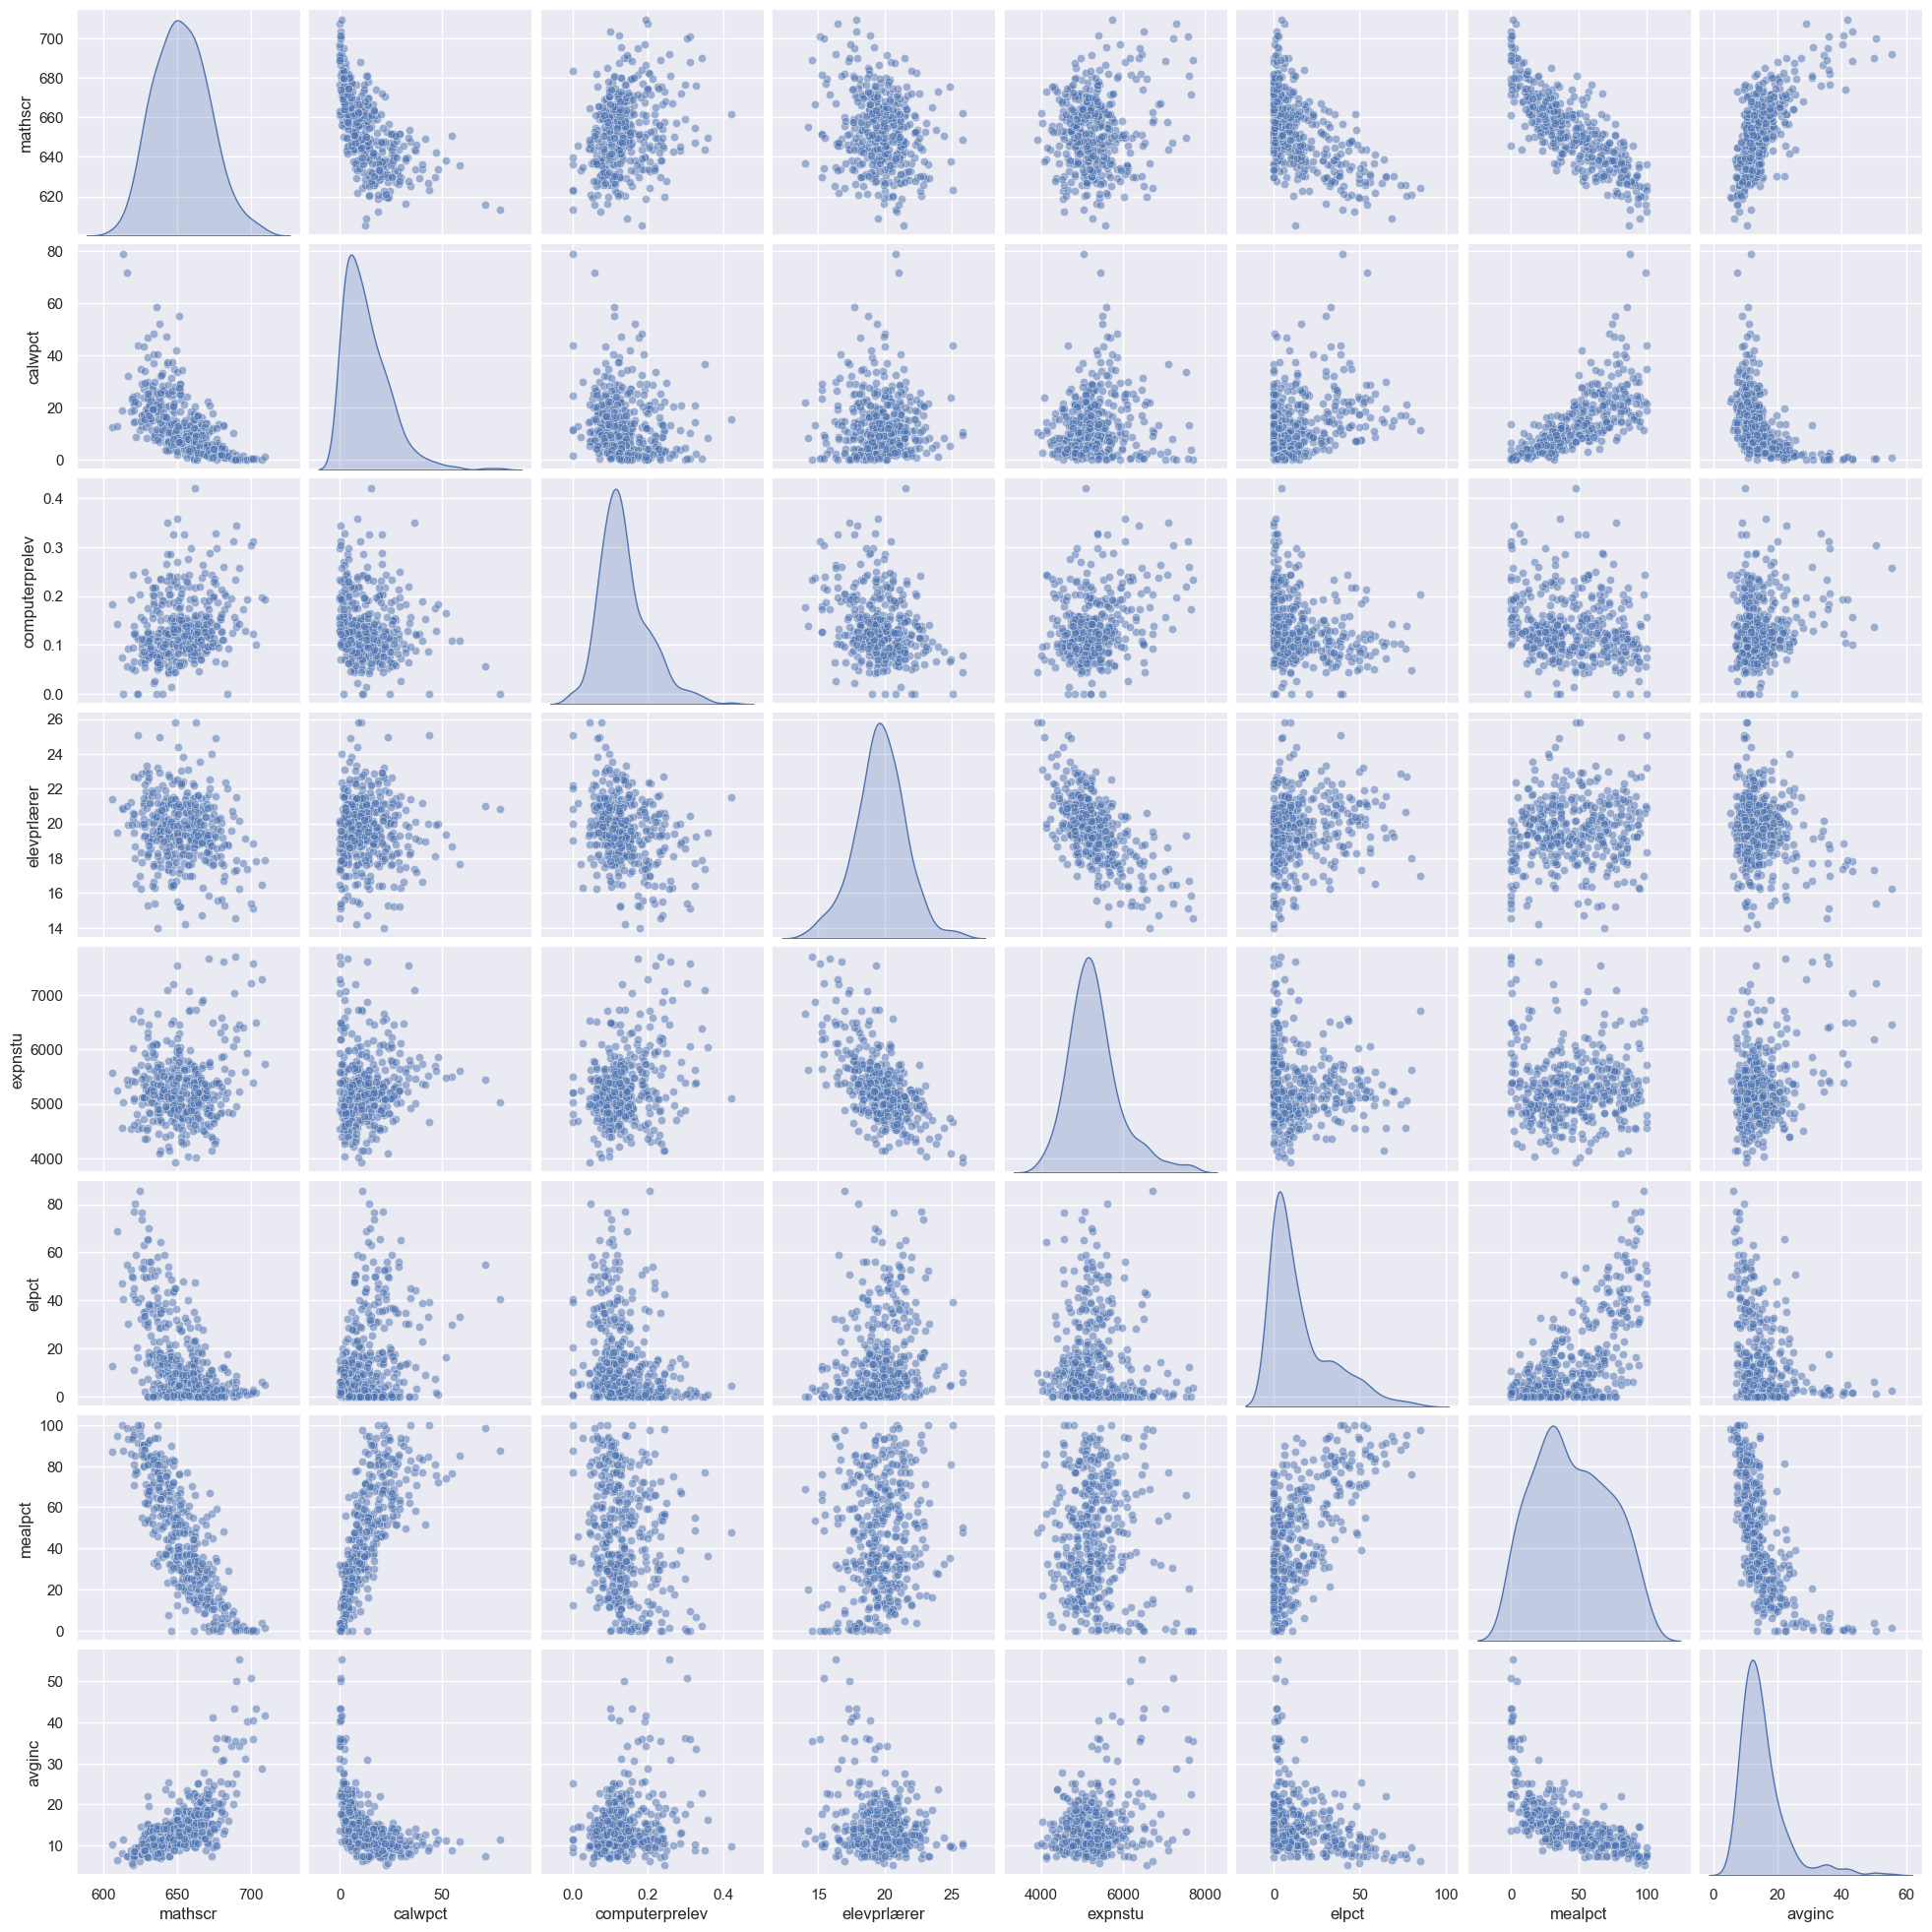

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vælg de kolonner du vil kigge på
cols = ['mathscr', 'calwpct', 'computerprelev', 'elevprlærer', 'expnstu', 'elpct', 'mealpct', 'avginc']

# Lav et pairplot
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

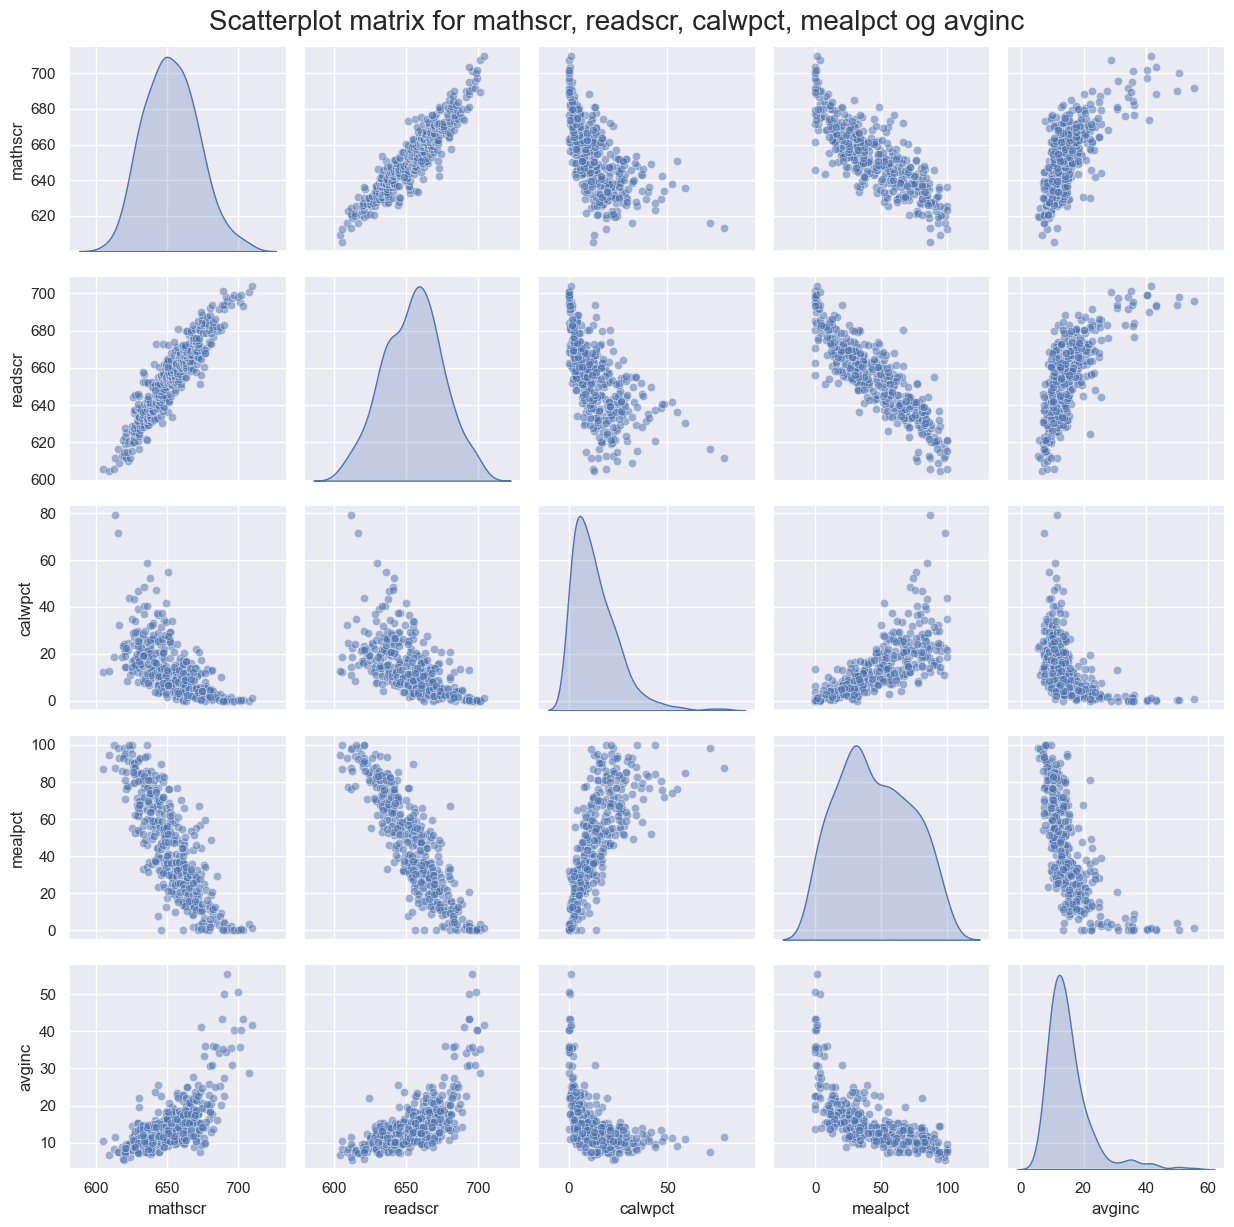

In [182]:

# Vælg de kolonner du vil kigge på
cols = ['mathscr', 'readscr', 'calwpct', 'mealpct', 'avginc']

# Lav et pairplot
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Scatterplot matrix for mathscr, readscr, calwpct, mealpct og avginc", fontsize=20)
plt.tight_layout()
plt.show()

,mathscr,readscr,calwpct,computerprelev,elevprlærer,expnstu,elpct,mealpct,avginc
mathscr,1.000000,0.922180,-0.609268,0.264950,-0.190254,0.143006,-0.577150,-0.823865,0.690651
readscr,0.922180,1.000000,-0.603379,0.292055,-0.243489,0.210504,-0.692756,-0.878397,0.689664
calwpct,-0.609268,-0.603379,1.000000,-0.155320,0.005449,0.078369,0.307715,0.735977,-0.503367
computerprelev,0.264950,0.292055,-0.155320,1.000000,-0.303635,0.290085,-0.257467,-0.210460,0.197167
elevprlærer,-0.190254,-0.243489,0.005449,-0.303635,1.000000,-0.630638,0.194062,0.128904,-0.225962
expnstu,0.143006,0.210504,0.078369,0.290085,-0.630638,1.000000,-0.071992,-0.053814,0.309250
elpct,-0.577150,-0.692756,0.307715,-0.257467,0.194062,-0.071992,1.000000,0.649948,-0.300229
mealpct,-0.823865,-0.878397,0.735977,-0.210460,0.128904,-0.053814,0.649948,1.000000,-0.682318
avginc,0.690651,0.689664,-0.503367,0.197167,-0.225962,0.309250,-0.300229,-0.682318,1.000000


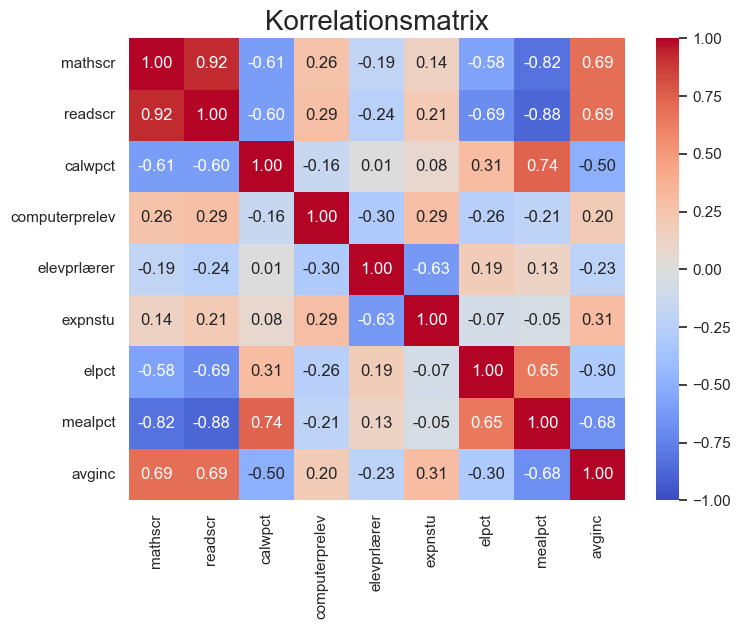

In [184]:


# Vælg de variable, du vil se korrelationen for
cols = ['mathscr','readscr', 'calwpct', 'computerprelev', 'elevprlærer', 'expnstu', 'elpct', 'mealpct', 'avginc']

corr = df[cols].corr()
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Korrelationsmatrix', fontsize=20)
plt.show()

Tanker om korrelationsplot: 
- Ingen tegn på linær sammenhæng mellem mulige forklarende variable 
- Mindsker risikoen for multikolinaritet

### b) Linear regression model

Overvejer mulige nonlineære led og interaktionsled: 

In [159]:
df['log_avginc'] = np.log(df['avginc'])
df['log_expnstu'] = np.log(df['expnstu'])
df['kvadreret_elev'] = df['enrltot']**2
df['avginc_computer_interaction'] = df['log_avginc'] * df['computerprelev']


In [160]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Define target variable
target = 'mathscr'

# Define list of potential predictors (adjust based on your dataset)
predictors = [ 'calwpct', 'computerprelev', 'elevprlærer', 'expnstu', 'elpct', 'avginc_computer_interaction', 'log_expnstu', 'kvadreret_elev', 'mealpct']  # Add or remove as needed

# Ensure predictors are in df and handle missing values if necessary
df_clean = df.dropna(subset=[target] + predictors)


# Function to perform forward selection using adjusted R² with constraints
def forward_selection(df, target, predictors):
    remaining = set(predictors)
    selected = ['log_avginc']
    current_score, best_new_score = 0.0, 0.0
    results = []
    
    # Dictionary for variable dependencies
    dependencies = {
        'avginc_computer_interaction': ['computerprelev']
    }
    
    while remaining and current_score == best_new_score:
        print(f"\nStep with selected: {selected}")
        scores_with_candidates = []
        for candidate in remaining:
            # Check if candidate has unmet dependencies
            required_vars = dependencies.get(candidate, [])
            missing_deps = [var for var in required_vars if var not in selected]
            
            if missing_deps:
                print(f"  Testing {candidate}: SKIPPED (requires {missing_deps})")
                continue
            
            formula = "{} ~ {}".format(target, ' + '.join(selected + [candidate]))
            model = sm.OLS.from_formula(formula, data=df).fit()
            score = model.rsquared_adj
            scores_with_candidates.append((score, candidate))
            print(f"  Testing {candidate}: Adjusted R² = {score:.4f}")
        
        if not scores_with_candidates:
            break
            
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        print(f"  Best candidate: {best_candidate} with Adjusted R² = {best_new_score:.4f}")
        
        if current_score < best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            results.append((selected.copy(), current_score))
    
    return results

# Run forward selection
selection_results = forward_selection(df_clean, target, predictors)

# Display results
print("Forward Selection Results (using adjusted R²):")
for i, (vars, adj_r2) in enumerate(selection_results, 1):
    print(f"Step {i}: Variables: {vars}, Adjusted R²: {adj_r2:.4f}")

# Final model
if selection_results:
    final_vars = selection_results[-1][0]
    formula = "{} ~ {}".format(target, ' + '.join(final_vars))
    final_model = sm.OLS.from_formula(formula, data=df_clean).fit()
    print("\nFinal Model Summary:")
    print(final_model.summary(slim=True))


Step with selected: ['log_avginc']
  Testing computerprelev: Adjusted R² = 0.5334
  Testing elpct: Adjusted R² = 0.6208
  Testing elevprlærer: Adjusted R² = 0.5138
  Testing expnstu: Adjusted R² = 0.5113
  Testing log_expnstu: Adjusted R² = 0.5120
  Testing mealpct: Adjusted R² = 0.6955
  Testing avginc_computer_interaction: SKIPPED (requires ['computerprelev'])
  Testing calwpct: Adjusted R² = 0.5749
  Testing kvadreret_elev: Adjusted R² = 0.5301
  Best candidate: mealpct with Adjusted R² = 0.6955

Step with selected: ['log_avginc', 'mealpct']
  Testing computerprelev: Adjusted R² = 0.7036
  Testing elpct: Adjusted R² = 0.7030
  Testing elevprlærer: Adjusted R² = 0.6994
  Testing expnstu: Adjusted R² = 0.6982
  Testing log_expnstu: Adjusted R² = 0.6977
  Testing avginc_computer_interaction: SKIPPED (requires ['computerprelev'])
  Testing calwpct: Adjusted R² = 0.6948
  Testing kvadreret_elev: Adjusted R² = 0.6968
  Best candidate: computerprelev with Adjusted R² = 0.7036

Step with s

In [166]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xs = df[['log_avginc', 'mealpct', 'computerprelev', 'elpct', 'calwpct', 'avginc_computer_interaction', 'elevprlærer']]

# Brug samme Xs som i modellen
X = sm.add_constant(Xs)

vif_df = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

display(vif_df)

,variable,VIF
0,const,565.819660
1,log_avginc,7.771268
2,mealpct,6.380442
3,computerprelev,38.300827
4,elpct,2.217185
5,calwpct,2.534804
6,avginc_computer_interaction,47.114124
7,elevprlærer,1.173016


Variabel indkomst i 1. model er signifikant med en p-værdi < 0,05. 

Overvejer hvilke variable der kunne have en betydning på math score: 
1. Calworks: Procentdel der kvalificere sig til CalWorks (income assistance). Angiver hvor stor en del fra skolens område der er fattige under en vis grænse? 
2. Elever pr. lærer: Ny variabel der forklare hvor mange lærer der er pr elev. Kan have indvirkning hvor meget tid hver elev har med lærer alene
3. Read: Hvis man er god til at læse, kan det være man også er god til matematik

Tester en efter en om variablen er signifikant og om det øjer adj. $R^2$

In [200]:
#Endelig model

Y = df[["mathscr"]]
Xs = df[['log_avginc', 'mealpct', 'computerprelev', 'elpct']]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model = sm.OLS(Y, X, missing="drop")
result = model.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.709
No. Observations:                 399   F-statistic:                     243.0
Covariance Type:            nonrobust   Prob (F-statistic):          6.08e-105
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            638.4501      6.652     95.979      0.000     625.372     651.528
log_avginc        11.4339      2.067      5.533      0.000       7.371      15.497
mealpct           -0.3839      0.036    -10.583      0.000      -0.455      -0.313
computerprelev    23.7141      8.050      2.946      0.003       7.887      39.541
elpct             -0.1078      0.039     -2.799      0.005      -0.184      -0.032

Notes:
[1] Standard Err

In [191]:
# Brug samme Xs som i modellen
X = sm.add_constant(Xs)

vif_df = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

display(vif_df)

,variable,VIF
0,const,172.246313
1,log_avginc,2.546284
2,mealpct,3.777233
3,computerprelev,1.076496
4,elpct,1.892664


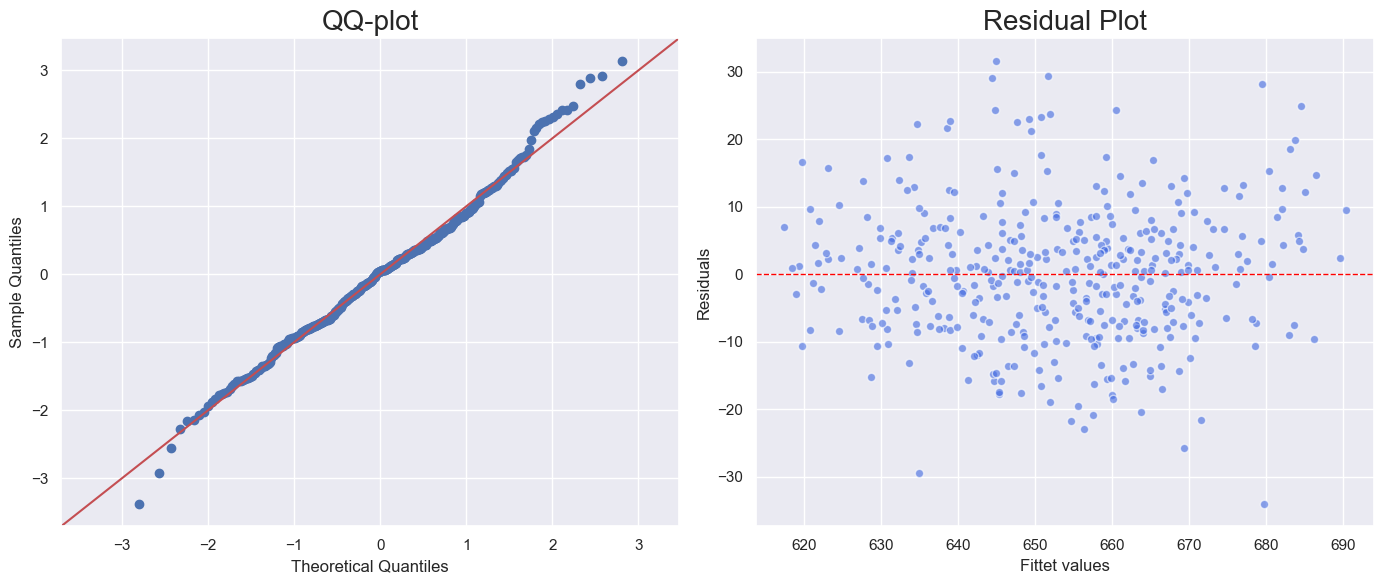

In [194]:

# 1. Hent fittede værdier og residualer fra din model
# (Her antager jeg at din model hedder 'model_log' eller lignende)
fitted_vals = result.fittedvalues
residuals = result.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(result.resid, line='45', fit=True, ax=axes[0])
axes[0].set_title('QQ-plot', size=20)

axes[1].scatter(result.fittedvalues, result.resid, alpha=0.6, color='royalblue', edgecolors='w')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residual Plot', size=20)
axes[1].set_xlabel('Fittet values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [196]:
# Beregn elasticiteter for hver variabel i modellen
# Elasticitet = (koefficient * gennemsnit_x) / gennemsnit_y for ikke-log variabler
# For log_avginc er koefficienten allerede elasticiteten

# Hent gennemsnit for y og x'er
mean_y = df['mathscr'].mean()
mean_log_avginc = df['log_avginc'].mean()
mean_mealpct = df['mealpct'].mean()
mean_computerprelev = df['computerprelev'].mean()
mean_elpct = df['elpct'].mean()

# Hent koefficienter fra modellen
coeff_log_avginc = result.params['log_avginc']
coeff_mealpct = result.params['mealpct']
coeff_computerprelev = result.params['computerprelev']
coeff_elpct = result.params['elpct']

# Beregn elasticiteter
elasticity_log_avginc = coeff_log_avginc / mean_y  # Korrekt ifølge slides
elasticity_mealpct = (coeff_mealpct * mean_mealpct) / mean_y
elasticity_computerprelev = (coeff_computerprelev * mean_computerprelev) / mean_y
elasticity_elpct = (coeff_elpct * mean_elpct) / mean_y

# Udskriv resultater
print(f"Elasticitet for log_avginc: {elasticity_log_avginc:.4f}")
print(f"Elasticitet for mealpct: {elasticity_mealpct:.4f}")
print(f"Elasticitet for computerprelev: {elasticity_computerprelev:.4f}")
print(f"Elasticitet for elpct: {elasticity_elpct:.4f}")

Elasticitet for log_avginc: 0.0175
Elasticitet for mealpct: -0.0264
Elasticitet for computerprelev: 0.0049
Elasticitet for elpct: -0.0025


Tanker om residualplottet: 
- Ingen tydelig bue, hvilket tyder på den lineær sammenhæng 
- Ingen outliers: ødelægger ikke modellen 
- Residualer fordeler sig pænt rundt om 0 
- Virker tilfældige

### f) Schools in San Diego County

In [164]:
df_sandiego

,Unnamed: 0,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
30,31,68379,San Diego,San Ysidro Elementary,KK-08,4142,201.000000,35.562500,81.506500,569,624.550049,0.137373,5342.233398,20.606966,6.613000,80.420090,620.400024,628.700012
68,69,68221,San Diego,National Elementary,KK-06,6639,304.730011,26.841400,100.000000,505,634.099976,0.076066,5339.391113,21.786499,8.423000,58.081036,631.500000,636.700012
117,118,68395,San Diego,South Bay Union Elementary,KK-06,10218,508.750000,17.420200,70.806396,1435,641.449951,0.140438,5518.702148,20.084520,10.602470,41.133293,638.599976,644.299988
145,146,68205,San Diego,Lemon Grove Elementary,KK-08,4612,232.970001,17.476101,65.915001,601,645.550049,0.130312,5124.836426,19.796539,12.827000,16.652212,647.700012,643.400024
159,160,68023,San Diego,Chula Vista Elementary,KK-06,21338,1051.579956,13.227200,45.994999,2889,647.250000,0.135392,5123.474121,20.291372,14.298300,34.337799,645.000000,649.500000
163,164,68098,San Diego,Escondido Union Elementary,KK-08,18255,903.760010,11.221700,58.533100,2001,648.000000,0.109614,5081.169922,20.198946,15.293799,39.594631,645.000000,651.000000
167,168,68437,San Diego,Vallecitos Elementary,KK-08,235,13.700000,6.808500,67.234001,51,648.700012,0.217021,5621.687988,17.153284,16.622999,39.574467,643.400024,654.000000
197,198,68155,San Diego,Jamul-Dulzura Union Elementary,KK-08,1221,61.599998,4.340700,25.307100,250,652.849976,0.204750,5169.814941,19.821428,19.025999,7.289107,656.799988,648.900024
213,214,68189,San Diego,Lakeside Union Elementary,KK-08,4928,229.199997,8.542000,25.888500,618,654.849976,0.125406,5139.937500,21.500874,14.623000,5.925324,653.500000,656.200012
234,235,67991,San Diego,Cajon Valley Union Elementary,KK-08,19294,924.570007,18.931900,50.970798,2401,657.000000,0.124443,5280.023438,20.868078,15.684654,16.663212,657.599976,656.400024


In [214]:
df_sandiego['log_avginc'] = np.log(df_sandiego['avginc'])
df_sandiego['computerprelev'] = df_sandiego['computer'] / df_sandiego['enrltot']
df_sandiego_pred = sm.add_constant(df_sandiego[['log_avginc', 'mealpct', 'computerprelev', 'elpct']])

forudsigelse_test = result.predict(df_sandiego_pred)

# Beregn MSE for San Diego forudsigelser
mse_sandiego = ((forudsigelse_test - df_sandiego['mathscr']) ** 2).mean()
print(f"MSE for San Diego predictions: {mse_sandiego:.4f}")


MSE for San Diego predictions: 111.7507


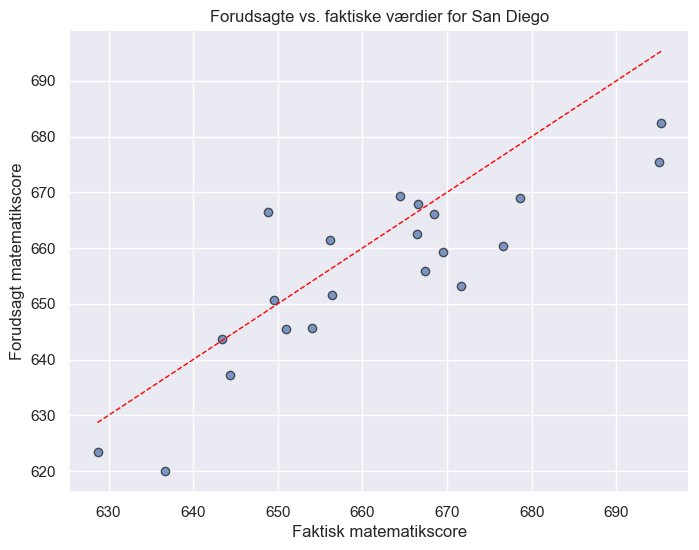

In [220]:
predicted_sandiego = result.predict(df_sandiego_pred)
actual_sandiego = df_sandiego['mathscr']

plt.figure(figsize=(8, 6))
plt.scatter(actual_sandiego, predicted_sandiego, alpha=0.7, edgecolor='k')
plt.plot([actual_sandiego.min(), actual_sandiego.max()],
         [actual_sandiego.min(), actual_sandiego.max()],
         color='red', linestyle='--', linewidth=1)
plt.xlabel('Faktisk matematikscore')
plt.ylabel('Forudsagt matematikscore')
plt.title('Forudsagte vs. faktiske værdier for San Diego')
plt.grid(True)
plt.show()

In [215]:

df_pred = sm.add_constant(df[['log_avginc', 'mealpct', 'computerprelev', 'elpct']])

forudsigelse_test = result.predict(df_pred)

# Beregn MSE for San Diego forudsigelser
mse_training = ((forudsigelse_test - df['mathscr']) ** 2).mean()
print(f"MSE for San Diego predictions: {mse_training:.4f}")

MSE for San Diego predictions: 101.2152


In [216]:
df_sandiego_pred.describe()

,const,log_avginc,mealpct,computerprelev,elpct
count,21.0,21.000000,21.000000,21.000000,21.000000
mean,1.0,2.790680,40.296505,0.129811,22.195143
std,0.0,0.382376,26.104483,0.056778,20.501334
min,1.0,1.889037,2.611600,0.000000,1.320423
25%,1.0,2.660141,22.163601,0.124443,5.925324
50%,1.0,2.792453,36.702099,0.135123,16.652212
75%,1.0,2.945806,58.533100,0.158930,34.337799
max,1.0,3.653992,100.000000,0.218085,80.420090


In [217]:
df_pred.describe()

,const,log_avginc,mealpct,computerprelev,elpct
count,399.0,399.000000,399.000000,399.000000,399.000000
mean,1.0,2.637165,44.937275,0.136249,15.429893
std,0.0,0.391856,27.187718,0.065405,18.127411
min,1.0,1.674289,0.000000,0.000000,0.000000
25%,1.0,2.364056,23.541451,0.092863,1.780019
50%,1.0,2.612273,42.446800,0.124060,8.662933
75%,1.0,2.862658,66.927853,0.167880,22.781713
max,1.0,4.013279,100.000000,0.420833,85.539719
